# Cointegration pairs trading on an energy pair

The classic beginner version of this analysis regresses an oil equity on the crude price
and reads off R-squared. That is a **spurious-regression trap**: two random walks show a
high R-squared just because both trend. This notebook does it properly:

1. test each leg for **non-stationarity** (ADF),
2. test the pair for **cointegration** (Engle-Granger and Johansen),
3. measure the spread's mean-reversion **half-life**,
4. trade the spread as a z-score with a **rolling, look-ahead-free** signal, and
5. compare against the same strategy run **with look-ahead** to expose the inflation.

It runs on a synthetic cointegrated pair with known properties; switch
`get_pair_data(source="yahoo")` to run it on real tickers.

In [1]:
import sys; sys.path.insert(0, "..")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams.update({"figure.figsize": (11, 4), "figure.dpi": 110,
                     "axes.grid": True, "grid.alpha": 0.25, "font.size": 9})

from src.data import get_pair_data
from src.cointegration import adf_test, engle_granger, johansen_test, half_life
from src.pairs import rolling_signal, naive_signal, backtest_pair, buy_and_hold

## 1. The pair

Two log-price series sharing a common stochastic trend. `true_spread` and `true_beta` are ground-truth columns we validate against.

In [2]:
df = get_pair_data()
print(df.shape)
df.head()

(2087, 6)


,y,x,log_y,log_x,true_spread,true_beta
date,,,,,,
2017-01-02,91.311265,70.251893,4.514274,4.252087,0.000000,0.85000
2017-01-03,91.744781,69.557590,4.519011,4.242155,0.013136,0.85001
2017-01-04,94.090456,69.013824,4.544257,4.234307,0.045011,0.85002
2017-01-05,90.049370,65.885537,4.500358,4.187919,0.040501,0.85003
2017-01-06,95.025107,68.177418,4.554141,4.222113,0.065176,0.85004


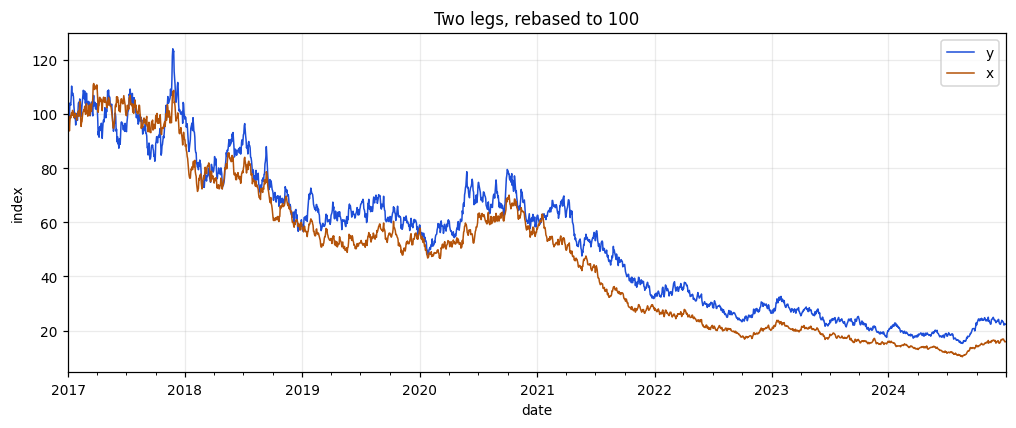

In [3]:
ax = (df[["y","x"]] / df[["y","x"]].iloc[0] * 100).plot(
        color=["#1d4ed8","#b45309"], lw=1.0, title="Two legs, rebased to 100")
ax.set_ylabel("index");

## 2. Stationarity and cointegration

Each leg should be non-stationary; only the combination should be stationary. If a leg were already stationary, ordinary regression would be fine and cointegration would be moot.

In [4]:
print("ADF log_y:", round(adf_test(df['log_y']).pvalue, 3), "-> non-stationary" )
print("ADF log_x:", round(adf_test(df['log_x']).pvalue, 3), "-> non-stationary")
eg = engle_granger(df["log_y"], df["log_x"])
print(f"\nEngle-Granger p-value: {eg.eg_pvalue:.4f}  cointegrated={eg.cointegrated}")
print(f"residual ADF p-value : {eg.resid_adf.pvalue:.4f}  hedge ratio beta={eg.beta:.3f}")
jo = johansen_test(df["log_y"], df["log_x"])
print(f"Johansen rank        : {jo.rank}  (1 = one cointegrating relation)")
print(f"spread half-life     : {half_life(eg.residual):.1f} days")

ADF log_y: 0.762 -> non-stationary
ADF log_x: 0.836 -> non-stationary

Engle-Granger p-value: 0.0000  cointegrated=True
residual ADF p-value : 0.0000  hedge ratio beta=0.822
Johansen rank        : 1  (1 = one cointegrating relation)
spread half-life     : 17.7 days


## 3. The spread and the signal

The cointegrating residual, normalised to a z-score on a trailing window. Enter past ±2σ, exit near zero. The hedge ratio and the normalisation use only past data.

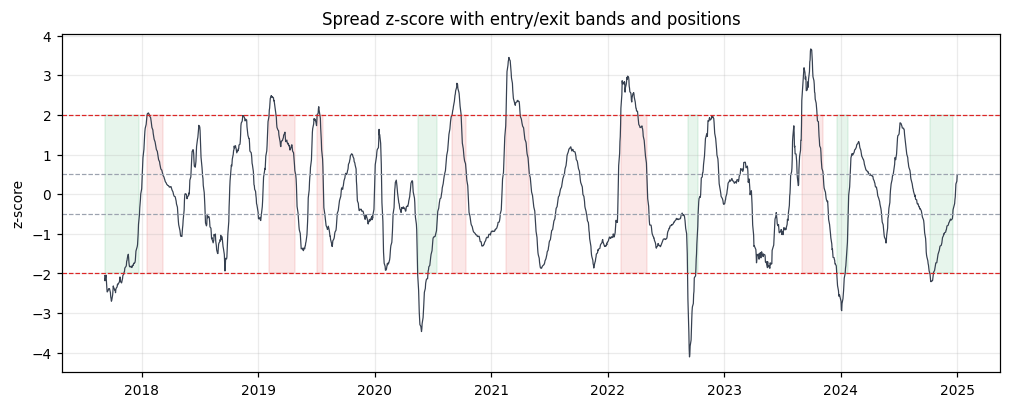

In [5]:
z, beta, pos = rolling_signal(df, window=90, entry=2.0, exit=0.5)
fig, ax = plt.subplots()
ax.plot(z.index, z, color="#374151", lw=0.8)
for lvl in (2, -2): ax.axhline(lvl, color="#dc2626", ls="--", lw=0.8)
for lvl in (0.5, -0.5): ax.axhline(lvl, color="#9ca3af", ls="--", lw=0.8)
ax.fill_between(z.index, -2, 2, where=(pos>0), color="#16a34a", alpha=0.10)
ax.fill_between(z.index, -2, 2, where=(pos<0), color="#dc2626", alpha=0.10)
ax.set_ylabel("z-score"); ax.set_title("Spread z-score with entry/exit bands and positions");

## 4. Backtest: achievable vs look-ahead

The rolling signal is what you could have traded in real time. The **naive** version estimates
the hedge ratio and z-score normalisation on the whole sample — using information from the future.
Comparing them shows how much of a typical pairs result is look-ahead.

In [6]:
bt = backtest_pair(df, pos, beta)            # rolling, out-of-sample
zn, betan, posn = naive_signal(df)
btn = backtest_pair(df, posn, betan)         # naive, look-ahead
comp = pd.DataFrame({"rolling_OOS": bt.stats, "naive_lookahead": btn.stats}).T
display(comp)
print(f"\nLook-ahead Sharpe inflation: {btn.stats['sharpe']/bt.stats['sharpe']:.2f}x")

,ann_return,ann_vol,sharpe,max_drawdown,hit_rate,n_trades,time_in_market
rolling_OOS,0.1336,0.1868,0.715,-0.3422,0.5248,24.0,0.251
naive_lookahead,0.2069,0.1276,1.622,-0.1085,0.6030,30.0,0.161



Look-ahead Sharpe inflation: 2.27x


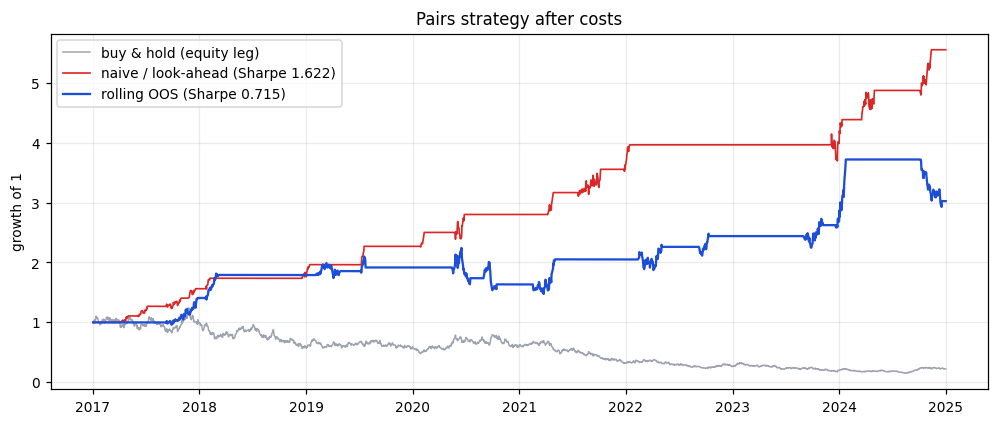

In [7]:
bh = buy_and_hold(df)
fig, ax = plt.subplots(figsize=(11, 4.2))
ax.plot(bh.index, bh, color="#9ca3af", lw=1.0, label="buy & hold (equity leg)")
ax.plot(btn.equity.index, btn.equity, color="#dc2626", lw=1.1,
        label=f"naive / look-ahead (Sharpe {btn.stats['sharpe']})")
ax.plot(bt.equity.index, bt.equity, color="#1d4ed8", lw=1.5,
        label=f"rolling OOS (Sharpe {bt.stats['sharpe']})")
ax.legend(); ax.set_ylabel("growth of 1"); ax.set_title("Pairs strategy after costs");

## Takeaways

- The two legs are individually non-stationary but cointegrated, so the spread mean-reverts — confirmed by Engle-Granger, Johansen, and a ~18-day half-life that matches the design.
- The achievable strategy earns a Sharpe near 0.7 after costs; the look-ahead version reports ~1.6 and a much shallower drawdown. The difference is information leakage, not skill.
- Net: the value of this project is the discipline. A single pair is fragile and the honest expectation on real data is lower, but the workflow — establish cointegration, trade the spread, validate without look-ahead, charge costs — is the part that holds up under scrutiny.

Switch `get_pair_data(source="yahoo", ticker_y="XOM", ticker_x="CVX")` to repeat on real data.